# Analysis of Data Distribution of Wrist-Angel Dataset

It will consist of the following distribution overviews: 
* Noise distribution - to measure the level of background noise (interference) per recording and accross different speaker segments
* Overall distribution of speech time per recording_id, i.e. how much of the complete dataset does speech from ID_4 make up.
* Distribution of speaker turns per recording
* Distribution of the total duration of speech spoken by adults vs adolescents
* Distribution of the total duration of speech spoken by women vs men
* Distribution of the total duration of speech spoken by the interviewer vs remainder of speakers
* Computing the distribution of the average length of utterances by speaker labels accross all recordings

In [1]:
# All imports for the notebook
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Analysis Plots
I will visualize the following, in order to create more meaningful evaluations of the results later..

In [2]:
columns = [
    'type',
    'file_id',
    'channel',
    'start',
    'duration',
    'ortho',
    'speaker_type',
    'speaker_name',
    'conf_score',
    'signal'
]

data = pd.read_csv('../results/ground_truth/transcripts.rttm', sep=r'\s+', names=columns)
data['end'] = data['start'] + data['duration']
data.head()

,type,file_id,channel,start,duration,ortho,speaker_type,speaker_name,conf_score,signal,end
0,SPEAKER,id18_baseline_suds,1,428,39,NaN,NaN,I,NaN,NaN,467
1,SPEAKER,id18_baseline_suds,1,467,1,NaN,NaN,B,NaN,NaN,468
2,SPEAKER,id18_baseline_suds,1,468,6,NaN,NaN,I,NaN,NaN,474
3,SPEAKER,id18_baseline_suds,1,474,3,NaN,NaN,B,NaN,NaN,477
4,SPEAKER,id18_baseline_suds,1,477,38,NaN,NaN,I,NaN,NaN,515


## Plot the SNR of the clips
In order to do this, I first need to estimate the noise part of the recordings. Since I am not given complete timestamps (start, end) I cannot know exactly what is noise and what is speech from the transcripts alone. Therefore, I will first run a blind round of VAD filtering on each of clips, and manually calculate the SNR for each utterance based on the values estimated per the original clips.

### Estimate SNR values per recording

In [4]:

import torchaudio
import torch
import torch.nn.functional as F

def estimate_snr_torchaudio(audio_path, clip_timestamps, top_db=20):
    # 1. Load audio
    path = os.path.join('l:/Auditdata/Wrist Angel - Video/Amalie Sommer/repo/thesis_multi_speaker_asr', audio_path)
    waveform, sr = torchaudio.load(path)
    if clip_timestamps:
        start = int(clip_timestamps[0] * sr)
        end = int(clip_timestamps[1] * sr)

        waveform = waveform[:, start:end]
    
    # Convert to mono if it's multi-channel
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
        
    # 2. Compute power across small windows (e.g., 30ms frames)
    window_size = int(sr * 0.03) 
    
    # Square the signal to get power
    power_signal = waveform ** 2
    
    # Use 1D average pooling to get the mean power for each window
    # F.avg_pool1d expects shape: (batch, channels, sequence_length)
    windowed_power = F.avg_pool1d(power_signal, kernel_size=window_size, stride=window_size).squeeze()
    
    # 3. Convert to decibels (add a tiny epsilon to avoid log of 0)
    power_db = 10 * torch.log10(windowed_power + 1e-10)
    
    # 4. Create speech/noise masks based on the peak volume
    threshold = torch.max(power_db) - top_db
    
    speech_mask = power_db > threshold
    noise_mask = ~speech_mask
    
    # Failsafe: if the audio is entirely flat (all speech or all silence)
    if not torch.any(speech_mask) or not torch.any(noise_mask):
        return float('nan') 
        
    # 5. Compute the final SNR
    mean_speech_power = torch.mean(windowed_power[speech_mask])
    mean_noise_power = torch.mean(windowed_power[noise_mask])
    
    snr_db = 10 * torch.log10(mean_speech_power / (mean_noise_power + 1e-10))
    
    return snr_db.item()

In [5]:
metadata_df = pd.read_csv('../data/wrist_angel_metadata.csv')
metadata_df.rename(columns={'audio_id': 'file_id'}, inplace=True)

for i, row in metadata_df.iterrows():
    audio = row['audio']
    start = row['start']
    end = row['end']
    snr = estimate_snr_torchaudio(audio_path=audio, clip_timestamps=(start, end))
    metadata_df.at[i, 'snr'] = snr
    

c:\Users\ATHO0358\Documents\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
c:\Users\ATHO0358\Documents\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.deco

In [6]:
print(metadata_df.columns)
print(data.columns)
merged_df = data.merge(metadata_df, on='file_id')
merged_df.head()
merged_df.drop(columns=['speaker_type', 'conf_score', 'signal', 'BORIS', 'start_y', 'end_y', 'Session', 'type', 'channel', 'ortho'], inplace=True)

Index(['patient_id', 'BORIS', 'audio', 'start', 'end', 'Session', 'file_id',
       'age', 'snr'],
      dtype='str')
Index(['type', 'file_id', 'channel', 'start', 'duration', 'ortho',
       'speaker_type', 'speaker_name', 'conf_score', 'signal', 'end'],
      dtype='str')


In [7]:
merged_df.head()
#merged_df.rename(columns={'start_x': 'start', 'end_x': 'end'}, inplace=True)

,file_id,start_x,duration,speaker_name,end_x,patient_id,audio,age,snr
0,id18_baseline_suds,428,39,I,467,WA 1018,data\\audio\\full_audio\\id18_baseline_suds.flac,13,15.986022
1,id18_baseline_suds,467,1,B,468,WA 1018,data\\audio\\full_audio\\id18_baseline_suds.flac,13,15.986022
2,id18_baseline_suds,468,6,I,474,WA 1018,data\\audio\\full_audio\\id18_baseline_suds.flac,13,15.986022
3,id18_baseline_suds,474,3,B,477,WA 1018,data\\audio\\full_audio\\id18_baseline_suds.flac,13,15.986022
4,id18_baseline_suds,477,38,I,515,WA 1018,data\\audio\\full_audio\\id18_baseline_suds.flac,13,15.986022


In [ ]:
import pandas as pd

# 2. Sort the data temporally to ensure segments are in chronological order
df = merged_df.sort_values(by=['file_id', 'start'])

# 3. Detect turn-takes
# Shift the speaker_id down by 1 row *within each audio_id group*
df['prev_speaker'] = df.groupby('file_id')['speaker_name'].shift(1)

# It's a turn-take if the speaker changes AND it's not the first segment (not NaN)
df['is_turn_take'] = (df['speaker_name'] != df['prev_speaker']) & df['prev_speaker'].notna()

# 4. Group by audio_id and aggregate
summary_df = df.groupby('file_id').agg(
    total_turn_takes=('is_turn_take', 'sum'),
    audio_start=('start', 'min'),
    audio_end=('end', 'max')
).reset_index()

# 5. Calculate rate per minute
summary_df['duration_minutes'] = (summary_df['audio_end'] - summary_df['audio_start']) / 60
summary_df['turn_takes_per_min'] = summary_df['total_turn_takes'] / summary_df['duration_minutes']

print(summary_df[['file_id', 'total_turn_takes', 'duration_minutes', 'turn_takes_per_min']])

## Include CoRal for Data Analysis + Plots

## Plot the distributions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

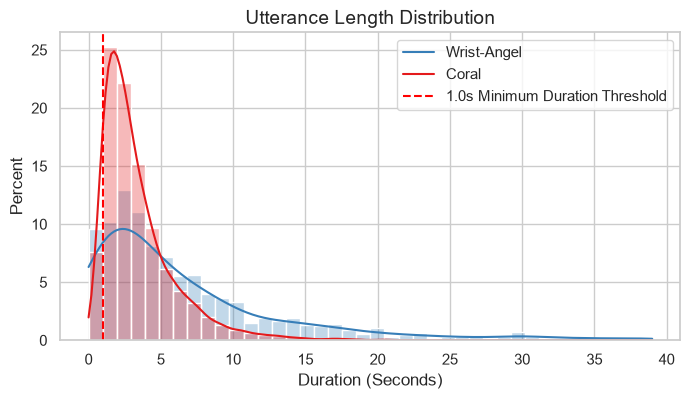

In [21]:
sns.set_theme(style="whitegrid")

coral_data = pd.read_csv('L:/Auditdata/Wrist Angel - Video/Amalie Sommer/repo/thesis_multi_speaker_asr/coral_v3_utterance_lengths.csv')
wrist_angel_data = merged_df[['duration', 'file_id']]
wrist_angel_data = wrist_angel_data.rename(columns={'duration': 'utterance_length_sec'})
wrist_angel_data['dataset_name'] = 'wrist_angel'
combined_data = pd.concat([coral_data, wrist_angel_data])

combined_data = combined_data[combined_data['utterance_length_sec'] < 40]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=combined_data, 
    x='utterance_length_sec', 
    hue='dataset_name',       # This separates the data into two colors
    kde=True, 
    bins=40,
    alpha=0.3,                # Makes the overlap visible
    palette='Set1',           # Good contrasting colors
    stat='percent',
    common_norm=False         # Normalizes KDEs independently if dataset sizes differ
)

# Keep your vertical line and styling
plt.axvline(1.0, color='red', linestyle='--')
plt.title('Utterance Length Distribution', fontsize=14)
plt.xlabel('Duration (Seconds)')

# Seaborn auto-generates a legend for 'hue', so we just need to ensure the axvline is added to it
plt.legend(
    labels=['Wrist-Angel', 'Coral', '1.0s Minimum Duration Threshold'],
    frameon=True,
    loc='upper right'
)

In [ ]:
sns.violinplot(data=merged_df, y='snr', inner='quartile')
plt.axhline(10, linestyle='--', label='Low SNR (<10 dB)')
plt.title('Signal-to-Noise Ratio (SNR) Distribution', fontsize=14)
plt.ylabel('SNR (dB)')
plt.legend()

In [ ]:
sns.kdeplot(data=summary_df, x='turn_takes_per_min', fill=True)
plt.title('Turn-Take Frequency Density', fontsize=14)
plt.xlabel('Turn-Takes per Minute')

## Speaker-based distributions
These will make use of the RTTM file format, in order to plot and show the distribution of speaker turns etc...
Note the RTTM file format is as follows:

Type, File-ID, Channel-ID, Turn Onset, Turn Duration, Orthographic Field, Speaker Type, Speaker Name, Confidence Score. (See example below)

SPEAKER id18_baseline_suds 1 428 39 <\NA> <\NA> I <\NA> <\NA>

In [ ]:
full_information = []
with open('../results/ground_truth/transcripts.rttm', 'r') as file:
    id_information = []
    audio_id = 0
    for line in file:
        line = line.strip()
        if len(line) == 0:
            continue
        labels = line.split(' ')
        if audio_id == None:
            audio_id = labels[1]
            id_information.append({
                'audio_id': labels[1],
                'start_time': labels[3],
                'duration': labels[4],
                'speaker_label': labels[7]
            })
        elif audio_id == labels[1]:
            id_information.append({
                'audio_id': labels[1],
                'start_time': labels[3],
                'duration': labels[4],
                'speaker_label': labels[7]
            })
        elif audio_id != labels[1]:
            full_information.append(id_information)
            id_information = [{
                'audio_id': labels[1],
                'start_time': labels[3],
                'duration': labels[4],
                'speaker_label': labels[7]
            }]
            audio_id = labels[1]
    full_information.append(id_information)


In [23]:
columns = [
    'type',
    'file_id',
    'channel',
    'start',
    'duration',
    'ortho',
    'speaker_type',
    'speaker_name',
    'conf_score',
    'signal'
]

df = pd.read_csv('../results/ground_truth/transcripts.rttm', sep=r'\s+', names=columns)
df['end'] = df['start'] + df['duration']

In [24]:
df.head()

,type,file_id,channel,start,duration,ortho,speaker_type,speaker_name,conf_score,signal,end
0,SPEAKER,id18_baseline_suds,1,428,39,NaN,NaN,I,NaN,NaN,467
1,SPEAKER,id18_baseline_suds,1,467,1,NaN,NaN,B,NaN,NaN,468
2,SPEAKER,id18_baseline_suds,1,468,6,NaN,NaN,I,NaN,NaN,474
3,SPEAKER,id18_baseline_suds,1,474,3,NaN,NaN,B,NaN,NaN,477
4,SPEAKER,id18_baseline_suds,1,477,38,NaN,NaN,I,NaN,NaN,515


In [25]:
label_counts = df.groupby(['file_id', 'speaker_name']).size().reset_index(name='num_utterances')
print(label_counts)

                   file_id speaker_name  num_utterances
0       id18_baseline_suds            B              21
1       id18_baseline_suds            I              27
2       id18_baseline_suds            V              17
3   id38_baseline_exposure            B              59
4   id38_baseline_exposure            I              48
..                     ...          ...             ...
65     id6_week8_exposure1            I              25
66     id6_week8_exposure1            V              17
67     id6_week8_exposure2            B              15
68     id6_week8_exposure2            I               2
69     id6_week8_exposure2            V              14

[70 rows x 3 columns]


In [26]:
label_percentages = label_counts.groupby('speaker_name')['num_utterances'].sum().pipe(lambda x: x / x.sum() * 100).reset_index(name='percentage')
print(label_percentages)

  speaker_name  percentage
0            B   42.681048
1            I   43.220339
2            V   14.098613


In [27]:
metadata_df = pd.read_csv('../data/wrist_angel_metadata.csv')
metadata_df.rename(columns={'audio_id': 'file_id'}, inplace=True)
label_counts_df = pd.DataFrame(label_counts)
df_merged = label_counts_df.merge(metadata_df, on='file_id', how='outer')
df_merged.head()

,file_id,speaker_name,num_utterances,patient_id,BORIS,audio,start,end,Session,age
0,id18_baseline_suds,B,21,WA 1018,WA1018_baseline,data\\audio\\full_audio\\id18_baseline_suds.flac,425.0,1060.0,Baseline,13
1,id18_baseline_suds,I,27,WA 1018,WA1018_baseline,data\\audio\\full_audio\\id18_baseline_suds.flac,425.0,1060.0,Baseline,13
2,id18_baseline_suds,V,17,WA 1018,WA1018_baseline,data\\audio\\full_audio\\id18_baseline_suds.flac,425.0,1060.0,Baseline,13
3,id38_baseline_exposure,B,59,WA 1038,WA1038_baseline,data\\audio\\full_audio\\id38_baseline_exposur...,550.0,1313.0,Baseline,10
4,id38_baseline_exposure,I,48,WA 1038,WA1038_baseline,data\\audio\\full_audio\\id38_baseline_exposur...,550.0,1313.0,Baseline,10


In [28]:
for i, row in df_merged.iterrows():
    if row['speaker_name'] == 'I' or row['speaker_name'] == 'V':
        df_merged.at[i, 'age'] = 40

df_merged.head(10)


,file_id,speaker_name,num_utterances,patient_id,BORIS,audio,start,end,Session,age
0,id18_baseline_suds,B,21,WA 1018,WA1018_baseline,data\\audio\\full_audio\\id18_baseline_suds.flac,425.0,1060.0,Baseline,13
1,id18_baseline_suds,I,27,WA 1018,WA1018_baseline,data\\audio\\full_audio\\id18_baseline_suds.flac,425.0,1060.0,Baseline,40
2,id18_baseline_suds,V,17,WA 1018,WA1018_baseline,data\\audio\\full_audio\\id18_baseline_suds.flac,425.0,1060.0,Baseline,40
3,id38_baseline_exposure,B,59,WA 1038,WA1038_baseline,data\\audio\\full_audio\\id38_baseline_exposur...,550.0,1313.0,Baseline,10
4,id38_baseline_exposure,I,48,WA 1038,WA1038_baseline,data\\audio\\full_audio\\id38_baseline_exposur...,550.0,1313.0,Baseline,40
5,id38_baseline_exposure,V,1,WA 1038,WA1038_baseline,data\\audio\\full_audio\\id38_baseline_exposur...,550.0,1313.0,Baseline,40
6,id38_week8_exposure,B,9,WA 1038,WA1038_week8,data\\audio\\full_audio\\id38_week8_exposure.flac,386.0,509.0,Week 8,10
7,id38_week8_exposure,I,8,WA 1038,WA1038_week8,data\\audio\\full_audio\\id38_week8_exposure.flac,386.0,509.0,Week 8,40
8,id38_week8_exposure,V,4,WA 1038,WA1038_week8,data\\audio\\full_audio\\id38_week8_exposure.flac,386.0,509.0,Week 8,40
9,id47_baseline_exposure_2,B,45,WA 1047,WA1047_baseline,data\\audio\\full_audio\\id47_baseline_exposur...,263.0,1060.5,Baseline,14


In [31]:
# Map ages to groups
df_merged["age_group"] = df_merged["age"].map(
    lambda x: "<13" if x < 13 else "13-18" if x <= 18 else ">18"
)

# Count utterances (rows) by age group
age_percentages = (
    df_merged.groupby(['file_id', 'age_group'])
      .size()
      .pipe(lambda s: s / s.groupby(level='file_id').transform('sum') * 100)
      .reset_index(name="percentage")
)

print(age_percentages)

                     file_id age_group  percentage
0         id18_baseline_suds     13-18   33.333333
1         id18_baseline_suds       >18   66.666667
2     id38_baseline_exposure       <13   33.333333
3     id38_baseline_exposure       >18   66.666667
4        id38_week8_exposure       <13   33.333333
5        id38_week8_exposure       >18   66.666667
6   id47_baseline_exposure_2     13-18   33.333333
7   id47_baseline_exposure_2       >18   66.666667
8   id47_baseline_exposure_3     13-18   33.333333
9   id47_baseline_exposure_3       >18   66.666667
10     id47_week8_exposure_2     13-18   50.000000
11     id47_week8_exposure_2       >18   50.000000
12     id47_week8_exposure_3     13-18   33.333333
13     id47_week8_exposure_3       >18   66.666667
14    id4_baseline_exposure1       <13   33.333333
15    id4_baseline_exposure1       >18   66.666667
16    id4_baseline_exposure2       <13   33.333333
17    id4_baseline_exposure2       >18   66.666667
18       id4_week8_exposure1   

In [ ]:
test = df.sort_values(['duration'], ascending=[False])
print(test)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(
    x='speaker_name', y='duration', data=df, palette='Set2', ax=ax, boxprops={'alpha': 0.8}
)
ax.set_xlabel('Speaker')
ax.set_ylabel('Duration (s)')
ax.set_title('Turn-taking Duration Distribution')
plt.show()

This essentially shows that as expected the interviewer has a tendency to speak for longer durations than that of the child and the parent. The difference between the speaker turn duration of the adolescent and their parent is mainly found in the amount of outliers. This could be due to the large age variation of the adolescent data group, since it spans the ages of 10 to 16. 

In [ ]:
transition_list = []
for file_id, group in df.groupby('file_id'):
    sorted_group = group.sort_values('start')
    speakers_seq = df['speaker_name']

    for (s1, s2) in zip(speakers_seq[:-1], speakers_seq[1:]):
        transition_list.append({'prev': s1, 'next': s2})

transition_df = pd.DataFrame(transition_list)
if not transition_df.empty:
    unique_speakers = sorted(df['speaker_name'].unique())
    transition_matrix = pd.crosstab(
        transition_df['prev'],
        transition_df['next']
    ).reindex(index=unique_speakers, columns=unique_speakers, fill_value=0)


    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Next Speaker')
    ax.set_ylabel('Previous Speaker')
    ax.set_title('Speaker-based Transition Matrix')
    plt.show()

This heatmap suggests that the flow of the conversations follows a near interview-style format in which the primary interaction lies between the child and the interviewer, with much more limited interactions between the parent and either of the other two participant types. While this is expected, it is also noticable that the speaker type which most frequently follows up their own speech turn is the child speaker. This does match well-established speech patterns amongst children and younger adolescents, which have been shown to be more prone to speak in short but frequent outbursts rather than longer cohesive speech turns, which is the more predominant speech pattern of adults.

In [ ]:
speaker_stats = df.groupby('speaker_name').agg(
    turn_count=('duration', 'count'),
    total_duration=('duration', 'sum')
).reset_index()


stats = speaker_stats.melt(
    id_vars='speaker_name',
    value_vars=['turn_count', 'total_duration'],
    var_name='Metric',
    value_name='Value'
)

stats['Metric'] = stats['Metric'].replace({
    'turn_count': 'Number of turns',
    'total_duration': 'Total Duration (s)'
})

fig, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=stats,
    x='speaker_name',
    y='Value',
    hue='Metric',
    palette='Set2',
    ax=ax1
)

ax1.set_xlabel('Speaker')
ax1.set_ylabel('Count / Duration')
ax1.set_title('Speaker Turn Frequency vs. Speaker Total Duration')
ax1.legend(title='Metric')
plt.show()

This comparative bar plot indicates that the speech patterns between the adolescent speaker and the interviewer is quite similar. However, the speaker associated with speaker label 'I' is attributed to one person accross the complete dataset, whereas the identities attached to the speaker label 'B' varies accross different recordings. Therefore, this distribution will be checked for possible internal variability surrounding age groups. Since the ages range from 10 to 16, the age groups will be split by children (<= 13) and adolescents/teenagers (>13). 

In [ ]:
metadata_df = pd.read_csv('..\\data\\wrist_angel_metadata.csv')
print(metadata_df.columns)
metadata_df.head()

In [ ]:
age_list = metadata_df[['id', 'age', 'patient_id']].set_index('id').to_dict(orient='index')
print(age_list)

for i, row in df.iterrows():
    age = age_list[row['file_id']]['age']
    df.at[i, 'age'] = age
    id = age_list[row['file_id']]['patient_id']
    df.at[i, 'speaker_id'] = id



In [ ]:
speaker_b_df = df[df['speaker_name'] == 'B'].copy()
#speaker_b_df['duration'] = speaker_b_df['duration'] / 60
print(set(speaker_b_df['age']))
age_threshold = 13
speaker_b_df['age_group'] = speaker_b_df['age'].apply(
    lambda x: f'>{age_threshold}' if x > age_threshold else f'<{age_threshold}'
)

age_stats = speaker_b_df.groupby('age_group').agg(
    turn_count=('duration', 'count'),
    total_duration=('duration', 'sum')
).reset_index()

total_age_stats = age_stats.melt(
    id_vars='age_group',
    value_vars=['turn_count', 'total_duration'],
    var_name='Metric',
    value_name='Value'
)

total_age_stats['Metric'] = total_age_stats['Metric'].replace({
    'turn_count': 'Number of turns',
    'total_duration': 'Total Duration (min)'
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=total_age_stats,
    x='age_group',
    y='Value',
    hue='Metric',
    palette='Paired',
    ax=ax
)

ax.set_xlabel('Age Category')
ax.set_ylabel('Count / Duration')
ax.set_title('Turn Frequency vs. Duration By Age Group of the Speaker Label: \"Barn\"')
ax.legend(title='Metric')
plt.show()


While the internal distribution does show a difference between how the flow of conversation is handled by the different age groups, mainly in terms of how many speech turns the child age group has in additition to the adolescent group. The speech patterns do not differ enough to attribute it as significant. Furthermore, the speech duration distribution accross the dataset is heavily scewed towards the younger age group, given that the overall speech duration is made up off samples from a few recordings of the same speaker ids. This could mean an incorrect representation of the conversational pattern amongst the younger age group, given that there might be an overrepresentation of a few speakers, which could lead to a that speech pattern being the one reflected the most. Just to test this theory, the following plot will show the total duration within each age group spread out by speaker_id.

In [ ]:
print(speaker_b_df['duration'])

In [ ]:
speaker_b_df['age_group'] = speaker_b_df['age'].apply(
    lambda x: f'>{age_threshold}' if x > age_threshold else f'<{age_threshold}'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=speaker_b_df,
    x='age_group',
    y='duration',
    hue='speaker_id',
    palette='Set2',
    ax=ax,
    boxprops={'alpha': 0.8}
)

sns.stripplot(
    data=speaker_b_df,
    x='age_group',
    y='duration',
    hue='speaker_id',
    dodge=True,
    palette='dark:black',
    alpha=0.4,
    size=4,
    legend=False,
    ax=ax
)

ax.set_xlabel('Age Category')
ax.set_ylabel('Turn Duration (min)')
ax.set_ylim(0, 45)
ax.set_title('Speaker Duration Distribution by Speaker ID per Age Group')

handles, labels = ax.get_legend_handles_labels()
unique_count = len(speaker_b_df['speaker_id'].unique())
ax.legend(handles[:unique_count], labels[:unique_count], title='Speaker ID')

plt.show()

From the above plot, one can see that the speakers aged 13 or younger predominantly speak in utterances shorter than 10 seconds, compared to the adolescent speakers -- aged 14 or older -- who appear to speak predominantly in utterances closer to a range of 15 to 30 seconds.
Finally, a plot will be displayed to show the accumulative speaker duration accross the whole dataset and the percentage at which the speaker_ids contribute to that sum. This will be done using a simple bar and line chart.

In [ ]:
speaker_totals = (
    df.groupby('speaker_id')['duration']
    .sum()
    .reset_index()
    .sort_values(by='duration', ascending=False)
    .reset_index(drop=True)
)

speaker_totals['cumulative_duration'] = speaker_totals['duration'].cumsum()
total_dataset_duration = speaker_totals['duration'].sum()
speaker_totals['cumulative_percentage'] = (
    speaker_totals['cumulative_duration'] / total_dataset_duration
) * 100

fig, ax1 = plt.subplots(figsize=(8, 4))
color = 'tab:blue'
ax1.set_xlabel('Speaker ID')
ax1.set_ylabel('Total Speaking Time (s)', color=color)
bars = ax1.bar(
    speaker_totals['speaker_id'],
    speaker_totals['duration'],
    color=color,
    alpha=0.8
)

ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Cumulative Share of Dataset (%)', color=color)
line = ax2.plot(
    speaker_totals['speaker_id'],
    speaker_totals['cumulative_percentage'],
    color=color,
    marker='o',
    linewidth=2
)
ax2.tick_params(axis='y', labelcolor=color)
#ax2.set_ylim(0, 100)

plt.title('Accumulated Total Speech and Dataset Share per Speaker ID')
fig.tight_layout()
plt.show()

This plot essentially shows what was suspected. That is, the majority of the dataset consists of a skewed distribution of the underlying speaker ids. Although, initially it was suspected that the majority of the dataset consisted of speech from a younger age group. But the former two plots indicate that in fact the opposite is true. 

# Quick Metadata Overview:

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('L:\\Auditdata\\Wrist Angel - Video\\Amalie Sommer\\repo\\thesis_multi_speaker_asr\\data\\audio\\segments\\metadata_new.csv')
print(df.shape)
short_utterances = df[df['segment_duration'] < 1.0]
print(short_utterances.shape)